<a href="https://colab.research.google.com/github/Jaychandrarevada/Innomatics-Internship-Tasks/blob/main/NLP_Task_4_FineTuning_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install transformers[torch] datasets evaluate scikit-learn accelerate -U

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 38.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 48.4 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling trans

In [3]:
from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import numpy as np
import evaluate

# 1. Load Dataset (IMDB Movie Reviews)
dataset = load_dataset('imdb')

# 2. Tokenization using bert-base-uncased
tokenizer = AutoTokenizer.from_pretrained('bert-base-uncased')

def tokenize_function(examples):
    return tokenizer(examples['text'], padding='max_length', truncation=True)

# Using a small subset for faster training demonstration, remove .select() for full training
tokenized_datasets = dataset.map(tokenize_function, batched=True)
train_dataset = tokenized_datasets['train'].shuffle(seed=42).select(range(1000))
eval_dataset = tokenized_datasets['test'].shuffle(seed=42).select(range(500))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

In [4]:
# 3. Model Building
model = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# 4. Evaluation Metrics
metric = evaluate.load('accuracy')

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    return metric.compute(predictions=predictions, references=labels)

# 5. Fine-Tuning Setup
training_args = TrainingArguments(
    output_dir='test_trainer',
    eval_strategy='epoch', # Updated from evaluation_strategy to fix the TypeError
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

print('Starting initial training...')
trainer.train()

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting initial training...


Epoch,Training Loss,Validation Loss


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.355948,0.848000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=125, training_loss=0.5461261596679687, metrics={'train_runtime': 123.1954, 'train_samples_per_second': 8.117, 'train_steps_per_second': 1.015, 'total_flos': 263111055360000.0, 'train_loss': 0.5461261596679687, 'epoch': 1.0})

Starting Experiment 2: Fine-tuning only the last 2 encoder layers...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.526606,0.768000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.79      0.78       254
    Positive       0.77      0.75      0.76       246

    accuracy                           0.77       500
   macro avg       0.77      0.77      0.77       500
weighted avg       0.77      0.77      0.77       500



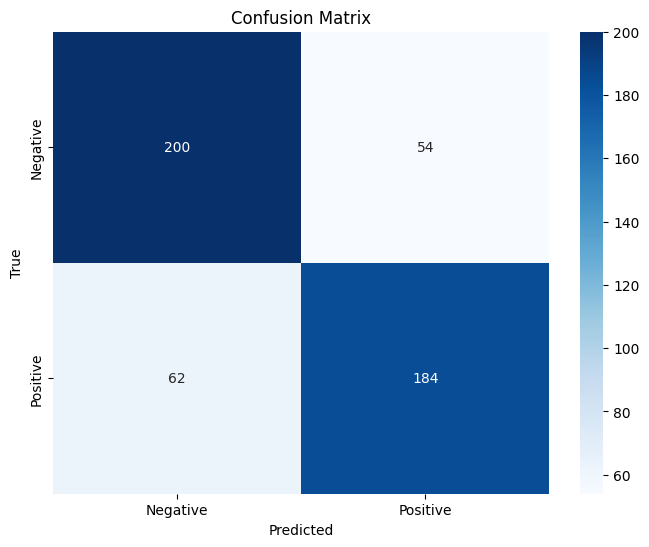

In [9]:
print('Starting Experiment 2: Fine-tuning only the last 2 encoder layers...')

# 1. Load a fresh model
model_partial = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# 2. Freeze all layers first
for param in model_partial.bert.parameters():
    param.requires_grad = False

# 3. Unfreeze the last two encoder layers (layer 10 and 11) and the pooler
# BERT-base has 12 layers (0-11)
for param in model_partial.bert.encoder.layer[10:].parameters():
    param.requires_grad = True

for param in model_partial.bert.pooler.parameters():
    param.requires_grad = True

trainer_partial = Trainer(
    model=model_partial,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

trainer_partial.train()
evaluate_model(trainer_partial, eval_dataset)

Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.76      0.84       254
    Positive       0.79      0.94      0.86       246

    accuracy                           0.85       500
   macro avg       0.86      0.85      0.85       500
weighted avg       0.86      0.85      0.85       500



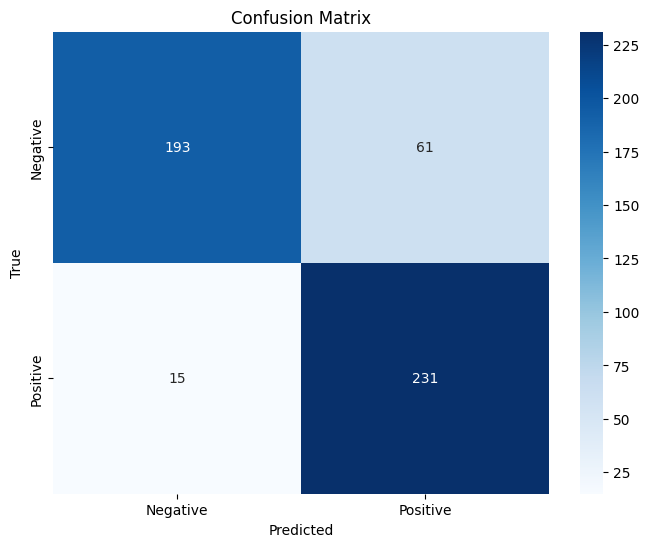

In [7]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 6. Detailed Model Evaluation
def evaluate_model(trainer, dataset):
    predictions = trainer.predict(dataset)
    preds = np.argmax(predictions.predictions, axis=-1)
    labels = predictions.label_ids

    # Classification Report (Accuracy, Precision, Recall, F1)
    print('Classification Report:')
    print(classification_report(labels, preds, target_names=['Negative', 'Positive']))

    # Confusion Matrix
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

evaluate_model(trainer, eval_dataset)

Starting Experiment: Freezing BERT layers...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy
1,No log,0.702608,0.454000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.46      0.49      0.48       254
    Positive       0.44      0.42      0.43       246

    accuracy                           0.45       500
   macro avg       0.45      0.45      0.45       500
weighted avg       0.45      0.45      0.45       500



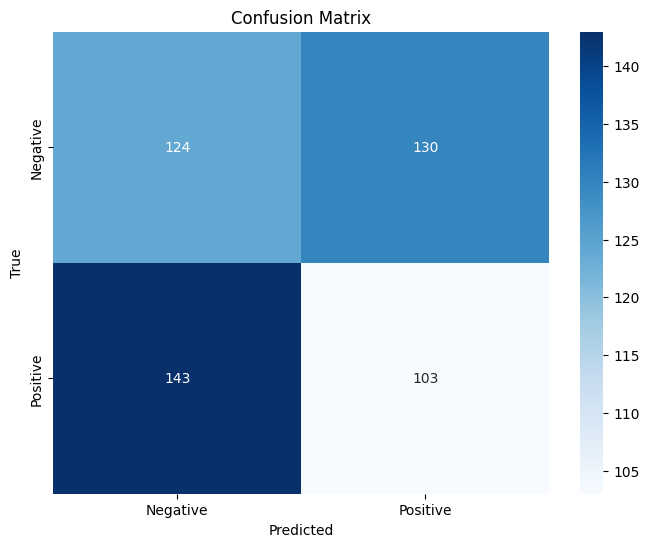

In [8]:
# 7. Experiment: Freeze BERT layers and train only the classifier
print('Starting Experiment: Freezing BERT layers...')

# Load a fresh model for the experiment
model_frozen = AutoModelForSequenceClassification.from_pretrained('bert-base-uncased', num_labels=2)

# Freeze all parameters in the BERT base model
for param in model_frozen.bert.parameters():
    param.requires_grad = False

trainer_frozen = Trainer(
    model=model_frozen,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    compute_metrics=compute_metrics,
)

trainer_frozen.train()
evaluate_model(trainer_frozen, eval_dataset)